# Movie Recommender System with Matrix Factorization (SVD)

**Goal:** build a collaborative filtering recommender using Singular Value Decomposition (SVD), and measure whether it actually beats a simple popularity baseline.

**Approach:** SVD-based collaborative filtering assumes user ratings can be explained by a small number of hidden factors (think: genre taste, mood, era preference) that aren't directly labeled in the data. By decomposing the user-movie rating matrix into `U`, `sigma`, and `Vt`, we can reconstruct a dense prediction matrix that fills in ratings for movies a user hasn't seen yet, based on patterns learned from everyone else.

**Dataset:** [MovieLens Latest Small](https://grouplens.org/datasets/movielens/latest/) (~100K ratings, ~600 users, ~9K movies). Unzip `ml-latest-small.zip` so the folder sits next to this notebook.

**Evaluation:** for each user, 20% of ratings are hidden before training. We measure:
- **RMSE** — how close predicted star ratings are to actual hidden ratings
- **Precision@10 / Recall@10** — of the top 10 movies recommended, how many did the user actually like (4+ stars) in the hidden set, compared against a popularity baseline

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse.linalg import svds

np.random.seed(42)

## 1. Load the Data

In [34]:
DATA_DIR = "ml-latest-small"

movies = pd.read_csv(f"{DATA_DIR}/movies.csv")
ratings = pd.read_csv(f"{DATA_DIR}/ratings.csv")

print("movies:", movies.shape)
print("ratings:", ratings.shape)
ratings.head()

movies: (9742, 3)
ratings: (100836, 4)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


## 2. Explore the Data

SVD needs a dense-enough matrix per user to find meaningful patterns, so it helps to know how sparse the data is up front.

610 users, 9724 movies, 100836 ratings
Sparsity: 98.30% of the user-movie matrix is empty


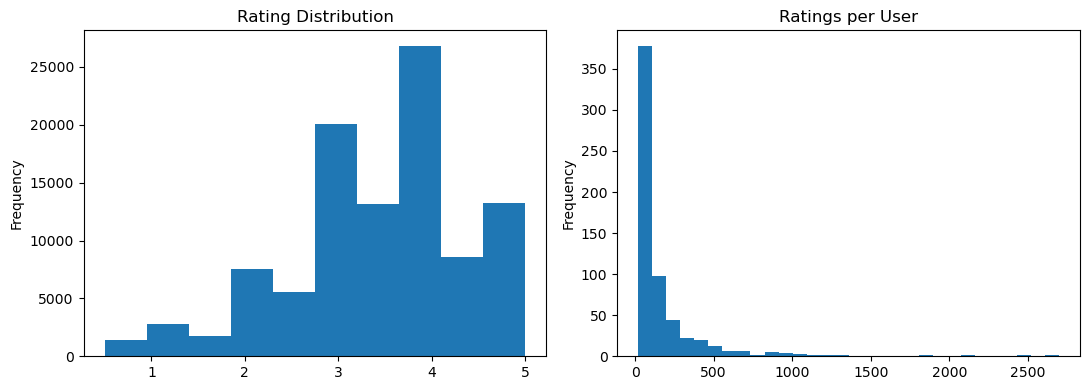

In [35]:
n_users = ratings["userId"].nunique()
n_movies = ratings["movieId"].nunique()
sparsity = 1 - len(ratings) / (n_users * n_movies)
print(f"{n_users} users, {n_movies} movies, {len(ratings)} ratings")
print(f"Sparsity: {sparsity:.2%} of the user-movie matrix is empty")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ratings["rating"].plot(kind="hist", bins=10, ax=axes[0], title="Rating Distribution")
ratings.groupby("userId").size().plot(kind="hist", bins=30, ax=axes[1], title="Ratings per User")
plt.tight_layout()
plt.show()

The rating distribution peaks around 4, meaning most ratings given are on the higher end of the scale. This is likely due to that fact that most users will typically only take the time to rate movies they enjoyed. The ratings-per-user distribution is skewed right — most users rate a relatively small number of movies, while a few number of users rate far more. Since users only rate a small fraction of the 9,724 available movies, most possible user-movie pairings are never filled in, which is why 98.3% of the matrix is empty.

## 3. Filter Rare Movies and Split Train/Test

Movies with very few ratings add noise without adding signal, so they're dropped before building the matrix. Then, for each user, 20% of their ratings are held out as a hidden test set — splitting *per user* guarantees every user appears in both train and test.

In [36]:
MIN_RATINGS = 10
movie_counts = ratings["movieId"].value_counts()
keep_ids = movie_counts[movie_counts >= MIN_RATINGS].index
ratings = ratings[ratings["movieId"].isin(keep_ids)].copy()
movies = movies[movies["movieId"].isin(keep_ids)].reset_index(drop=True)

print(f"After filtering: {ratings['userId'].nunique()} users, {movies.shape[0]} movies, {len(ratings)} ratings")

After filtering: 610 users, 2269 movies, 81116 ratings


In [37]:
ratings = ratings.sample(frac=1, random_state=42).reset_index(drop=True)
ratings["pos"] = ratings.groupby("userId").cumcount()
ratings["n_user"] = ratings.groupby("userId")["rating"].transform("size")

is_test = ratings["pos"] < 0.2 * ratings["n_user"]
train = ratings[~is_test].copy()
test = ratings[is_test].copy()

print(f"Train: {len(train)} ratings | Test: {len(test)} ratings")

Train: 64660 ratings | Test: 16456 ratings


## 4. Build the User-Item Matrix (Training Data Only)

This is the core structure for collaborative filtering: rows are users, columns are movies, and each cell is that user's rating (or blank if unrated). It's built from **training ratings only** — the test ratings stay hidden until evaluation.

In [38]:
user_item_matrix = train.pivot_table(index="userId", columns="movieId", values="rating")
print(user_item_matrix.shape)
user_item_matrix.head()

(610, 2269)


movieId,1,2,3,5,6,7,9,10,11,12,...,166461,166528,166643,168250,168252,174055,176371,177765,179819,187593
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,4.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Mean-Center the Ratings

Some users rate everything a 4 or 5; others are harsher critics who rarely go above a 3. Subtracting each user's average rating removes this bias so SVD learns *relative* preferences rather than just who's generous with stars. Missing values are then filled with 0 (the centered "neutral" point) so SVD has a complete matrix to decompose.

In [39]:
user_means = user_item_matrix.mean(axis=1)
centered_ratings = user_item_matrix.sub(user_means, axis=0)
centered_ratings = centered_ratings.fillna(0)
centered_ratings.head()

movieId,1,2,3,5,6,7,9,10,11,12,...,166461,166528,166643,168250,168252,174055,176371,177765,179819,187593
userId,,,,,,,,,,,,,,,,,,,,,
1,-0.339286,0.0,-0.339286,0.0,-0.339286,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.342857,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 6. Decompose with SVD

`svds` factors the matrix into three pieces: `U` (user factors), `sigma` (the strength of each factor), and `Vt` (movie factors). `k=10` means we're compressing all rating patterns down to 10 hidden dimensions — a form of dimensionality reduction that also smooths out noise in the sparse original matrix.

In [40]:
k = min(10, min(centered_ratings.shape) - 1)
U, sigma, Vt = svds(centered_ratings.to_numpy(), k=k)

# svds returns factors in ascending order of importance; flip to descending
order = np.argsort(sigma)[::-1]
sigma = sigma[order]
U = U[:, order]
Vt = Vt[order, :]

print("U:", U.shape, "| sigma:", sigma.shape, "| Vt:", Vt.shape)

U: (610, 10) | sigma: (10,) | Vt: (10, 2269)


## 7. Reconstruct Predicted Ratings

Multiplying the three factors back together reconstructs a **dense** matrix — no more missing values. Every user now has a predicted rating for every movie, including ones they've never seen. Adding back `user_means` reverses the centering from step 5, returning predictions to the original 0.5-5 star scale.

In [41]:
sigma_matrix = np.diag(sigma)
centered_prediction = np.dot(np.dot(U, sigma_matrix), Vt)
centered_prediction = pd.DataFrame(
    centered_prediction, index=user_item_matrix.index, columns=user_item_matrix.columns
)

predicted_ratings = centered_prediction.add(user_means, axis=0)
predicted_ratings.head()

movieId,1,2,3,5,6,7,9,10,11,12,...,166461,166528,166643,168250,168252,174055,176371,177765,179819,187593
userId,,,,,,,,,,,,,,,,,,,,,
1,4.391031,4.310344,4.314103,4.286368,4.300189,4.362826,4.325329,4.309819,4.351154,4.260556,...,4.338973,4.300903,4.346961,4.334184,4.324718,4.352282,4.333170,4.339385,4.392587,4.351504
2,3.945183,3.953410,3.945075,3.959806,3.951101,3.950758,3.950893,3.958431,3.949881,3.953037,...,3.949517,3.953712,3.949253,3.952042,3.952820,3.948950,3.950102,3.949787,3.942879,3.948534
3,1.521161,1.541658,1.515249,1.574458,1.564931,1.551586,1.516075,1.551708,1.520576,1.517262,...,1.523694,1.546062,1.524005,1.536276,1.538081,1.529465,1.522860,1.526879,1.473659,1.513509
4,3.902624,3.730560,3.753309,3.684837,3.720823,3.646698,3.769621,3.684246,3.646423,3.698579,...,3.741716,3.705894,3.733564,3.758248,3.720982,3.665152,3.695086,3.736592,3.762224,3.764223
5,3.699062,3.646079,3.666209,3.631223,3.658086,3.645974,3.655083,3.626250,3.650648,3.631110,...,3.658998,3.644535,3.657767,3.651605,3.643213,3.647793,3.644031,3.658418,3.677658,3.662672


## 8. Evaluate: RMSE on Held-Out Ratings

For every rating in the hidden test set, compare the SVD model's prediction to the actual star rating the user gave. RMSE (root mean squared error) tells us, on average, how many stars off the predictions are. Test ratings for movies that never appeared in training can't be predicted, so they're skipped (a known limitation of this approach called the *cold-start problem*).

In [42]:
test_eval = test[test["movieId"].isin(predicted_ratings.columns)]

preds = predicted_ratings.lookup(test_eval["userId"], test_eval["movieId"]) \
    if hasattr(predicted_ratings, "lookup") else \
    np.array([predicted_ratings.at[u, m] for u, m in zip(test_eval["userId"], test_eval["movieId"])])

actual = test_eval["rating"].values
rmse = np.sqrt(np.mean((preds - actual) ** 2))
print(f"Evaluated on {len(test_eval)}/{len(test)} test ratings (rest were cold-start movies)")
print(f"SVD RMSE: {rmse:.4f} stars")

Evaluated on 16456/16456 test ratings (rest were cold-start movies)
SVD RMSE: 0.8935 stars


## 9. Evaluate: Precision@10 / Recall@10 vs. a Popularity Baseline

RMSE alone doesn't tell us whether the *top 10 recommendations* are any good, and it doesn't say whether all this matrix factorization is even worth it over just recommending what's popular. This section builds both models and compares them head-to-head.

In [43]:
liked_test = test_eval[test_eval["rating"] >= 4]
relevant = {
    uid: set(group["movieId"])
    for uid, group in liked_test.groupby("userId")
}
print(f"{len(relevant)} users have at least one liked movie in the evaluable test set")

601 users have at least one liked movie in the evaluable test set


In [44]:
def evaluate(score_lookup_fn, k=10):
    """score_lookup_fn(user_id) -> pd.Series of scores indexed by movieId"""
    precisions, recalls = [], []
    for uid, rel in relevant.items():
        if uid not in user_item_matrix.index:
            continue
        seen = user_item_matrix.loc[uid].dropna().index
        scores = score_lookup_fn(uid).drop(index=seen, errors="ignore")
        top_k = set(scores.nlargest(k).index)
        hits = len(top_k & rel)
        precisions.append(hits / k)
        recalls.append(hits / len(rel))
    return np.mean(precisions), np.mean(recalls)

svd_p, svd_r = evaluate(lambda uid: predicted_ratings.loc[uid])
print(f"SVD CF      | Precision@10: {svd_p:.4f} | Recall@10: {svd_r:.4f}")

SVD CF      | Precision@10: 0.1293 | Recall@10: 0.1056


In [45]:
movie_popularity = train[train["rating"] >= 4]["movieId"].value_counts()
movie_popularity = movie_popularity.reindex(user_item_matrix.columns, fill_value=0)

pop_p, pop_r = evaluate(lambda uid: movie_popularity)
print(f"Popularity  | Precision@10: {pop_p:.4f} | Recall@10: {pop_r:.4f}")

Popularity  | Precision@10: 0.1306 | Recall@10: 0.1155


,Precision@10,Recall@10
Model,,
Popularity,0.1306,0.1155
SVD Collaborative Filtering,0.1293,0.1056


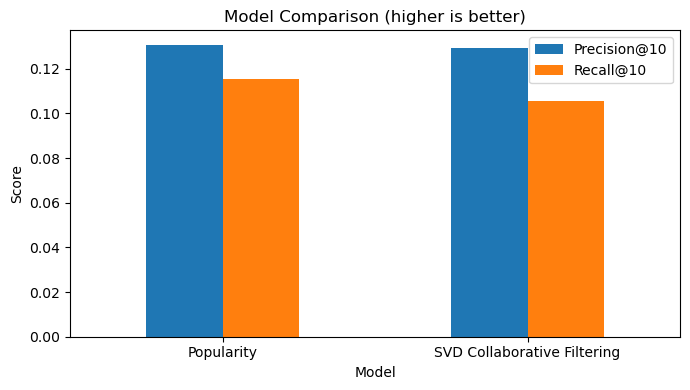

In [46]:
results = pd.DataFrame({
    "Model": ["Popularity", "SVD Collaborative Filtering"],
    "Precision@10": [pop_p, svd_p],
    "Recall@10": [pop_r, svd_r],
}).set_index("Model")

display(results.round(4))
results.plot(kind="bar", figsize=(7, 4), rot=0, title="Model Comparison (higher is better)")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

SVD didn't beat the popularity baseline (0.1293 vs. 0.1306 Precision@10), which is actually a useful finding, not just a bad result. This is probably because most users only rated a small number of movies, so SVD didn't have enough data to learn what each person actually likes. The popularity baseline doesn't have this problem since it doesn't try to personalize at all — it just recommends what's popular to everyone, no matter how much data exists for any one user. The RMSE was 0.8935, meaning predictions were typically off by about 0.89 stars. One limitation is that SVD only learns from rating patterns and never sees genre, plot, or other info about the movie itself — that's something a content-based model could use instead.
## 10. Get Recommendations for a User

In [ ]:
def collaborative_recommender(user_id, n=5):
    unseen_mask = user_item_matrix.loc[user_id].isna()
    predicted_for_unseen = predicted_ratings.loc[user_id, unseen_mask]
    top = predicted_for_unseen.nlargest(n)

    top = top.rename("predicted_rating").rename_axis("movieId").reset_index()
    result = pd.merge(top, movies, on="movieId", how="left")
    return result[["movieId", "title", "predicted_rating"]]

In [51]:
# Change the user ID to any userId in user_item_matrix.index
collaborative_recommender(user_item_matrix.index[5], n=5)

,movieId,title,predicted_rating
0,1097,E.T. the Extra-Terrestrial (1982),3.875355
1,260,Star Wars: Episode IV - A New Hope (1977),3.871300
2,1200,Aliens (1986),3.827040
3,1210,Star Wars: Episode VI - Return of the Jedi (1983),3.823256
4,2028,Saving Private Ryan (1998),3.819563


## Summary
This project built a movie recommender using SVD-based collaborative filtering, and compared it against a simple popularity baseline to see if the added complexity was worth it. On the MovieLens Latest Small dataset (610 users, 9,724 movies, 100,836 ratings), the SVD model got an RMSE of 0.8935 stars, meaning predictions were typically off by less than a star. For the recommendation quality, SVD scored 0.1293 Precision@10 and 0.1056 Recall@10, while the popularity baseline scored slightly higher at 0.1306 and 0.1155. This shows that on this dataset, the extra complexity of matrix factorization didn't pay off — likely because the data is very sparse (98.3% empty), so SVD doesn't have enough ratings per user to learn strong individual preferences. This is a useful finding: it shows that a more advanced technique isn't automatically better, and that testing against a simple baseline is important before assuming a complex model is worth using
